<a href="https://colab.research.google.com/github/angelc1052-dotcom/-0408/blob/main/%E8%B3%87%E6%96%99%E5%BA%AB%E8%99%95%E7%90%86.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_excel("SHOP_DATA_ADVANCED_220_ROWS.xlsx")
print(df.head())   # 檢查前幾筆


      order_id customer_id customer_segment product_id product_name  \
0  ORD20240001       C1072          Regular       P114        Boots   
1  ORD20240002       C1085          Regular       P108        Socks   
2  ORD20240003       C1070        Returning       P106     Backpack   
3  ORD20240004       C1040              VIP       P111        Scarf   
4  ORD20240005       C1084          Regular       P104          Hat   

      category  sub_category              supplier  unit_price  unit_cost  \
0     Footwear  Winter Shoes       StepOne Trading       96.20      49.49   
1     Footwear         Socks       StepOne Trading        6.25       3.29   
2  Accessories          Bags  Urban Accessory Ltd.       42.35      16.80   
3  Accessories      Neckwear  Urban Accessory Ltd.       15.63       6.72   
4  Accessories      Headwear  Urban Accessory Ltd.       15.67       6.30   

   ...       city     campaign  sale_date    month customer_rating returned  \
0  ...     Chiayi  No Campaign 

In [4]:
!pip install sqlalchemy pymysql pandas openpyxl matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 1.2 MB/s eta 0:00:00


In [5]:
from sqlalchemy import create_engine

host = "trolley.proxy.rlwy.net"
port = 15413
user = "root"
password = "ClAXeEgZVAjkVEzKJRDmwlrTBPiFlbJL"
database = "railway"

engine = create_engine(
    f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}?charset=utf8mb4"
)

print(f"Connected to MySQL at {host}:{port}, database={database}, user={user}")


Connected to MySQL at trolley.proxy.rlwy.net:15413, database=railway, user=root


In [6]:
from google.colab import files
import pandas as pd

uploaded = files.upload()   # 選擇 SHOP_DATA_ADVANCED_220_ROWS.xlsx

df = pd.read_excel("SHOP_DATA_ADVANCED_220_ROWS.xlsx")
print(df.head())


Saving SHOP_DATA_ADVANCED_220_ROWS.xlsx to SHOP_DATA_ADVANCED_220_ROWS (1).xlsx
      order_id customer_id customer_segment product_id product_name  \
0  ORD20240001       C1072          Regular       P114        Boots   
1  ORD20240002       C1085          Regular       P108        Socks   
2  ORD20240003       C1070        Returning       P106     Backpack   
3  ORD20240004       C1040              VIP       P111        Scarf   
4  ORD20240005       C1084          Regular       P104          Hat   

      category  sub_category              supplier  unit_price  unit_cost  \
0     Footwear  Winter Shoes       StepOne Trading       96.20      49.49   
1     Footwear         Socks       StepOne Trading        6.25       3.29   
2  Accessories          Bags  Urban Accessory Ltd.       42.35      16.80   
3  Accessories      Neckwear  Urban Accessory Ltd.       15.63       6.72   
4  Accessories      Headwear  Urban Accessory Ltd.       15.67       6.30   

   ...       city     campaign

In [7]:
df.to_sql("SHOP_DATA_ADVANCED_220_ROWS", con=engine, if_exists="replace", index=False)


220

In [8]:
print(pd.read_sql("SHOW TABLES", engine))
print(pd.read_sql("SELECT * FROM SHOP_DATA_ADVANCED_220_ROWS LIMIT 10", engine))


             Tables_in_railway
0  SHOP_DATA_ADVANCED_220_ROWS
1                   excel_data
2                    shop_data
      order_id customer_id customer_segment product_id product_name  \
0  ORD20240001       C1072          Regular       P114        Boots   
1  ORD20240002       C1085          Regular       P108        Socks   
2  ORD20240003       C1070        Returning       P106     Backpack   
3  ORD20240004       C1040              VIP       P111        Scarf   
4  ORD20240005       C1084          Regular       P104          Hat   
5  ORD20240006       C1062     New Customer       P109        Watch   
6  ORD20240007       C1008     New Customer       P116        Shoes   
7  ORD20240008       C1014     New Customer       P103     Sneakers   
8  ORD20240009       C1027              VIP       P107      Sandals   
9  ORD20240010       C1051          Regular       P104          Hat   

      category  sub_category              supplier  unit_price  unit_cost  \
0     Footwear  W

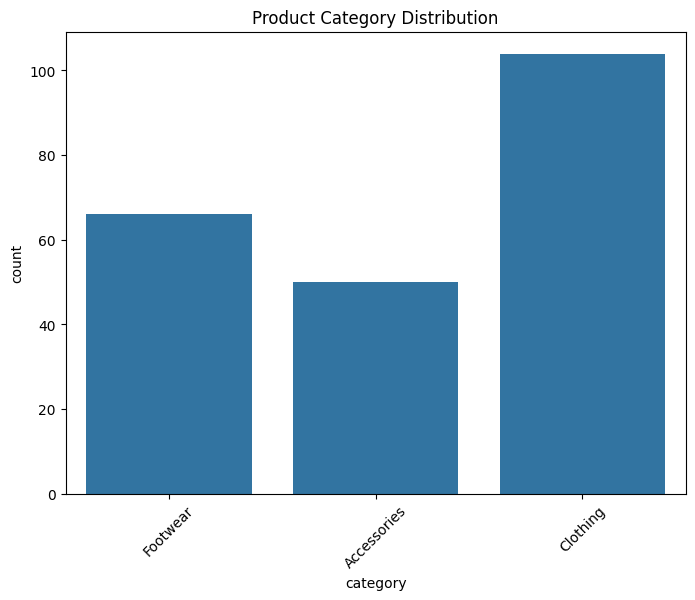

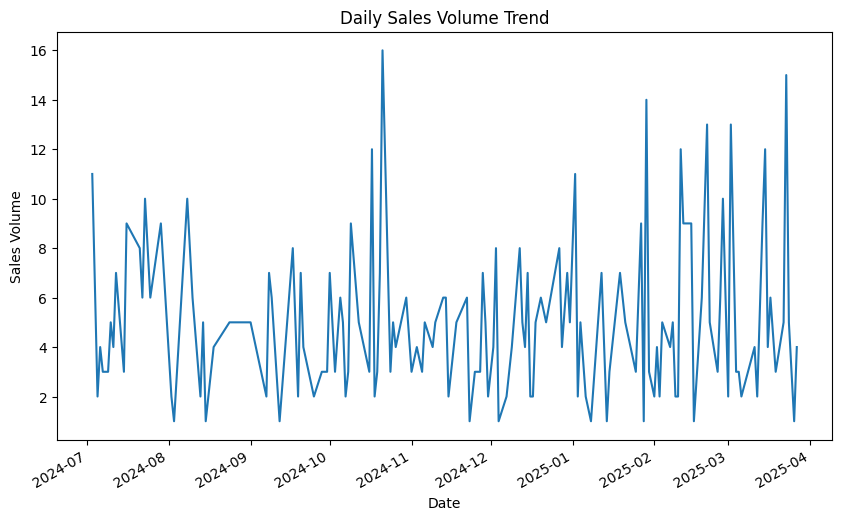

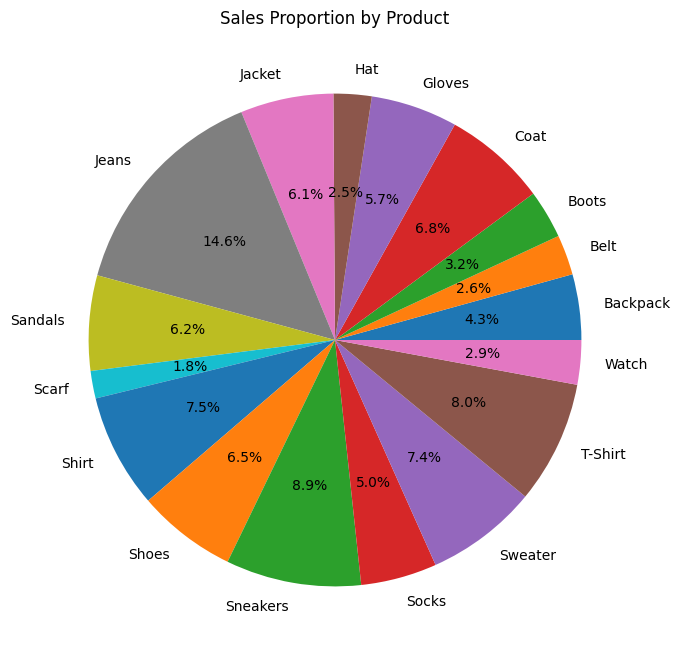

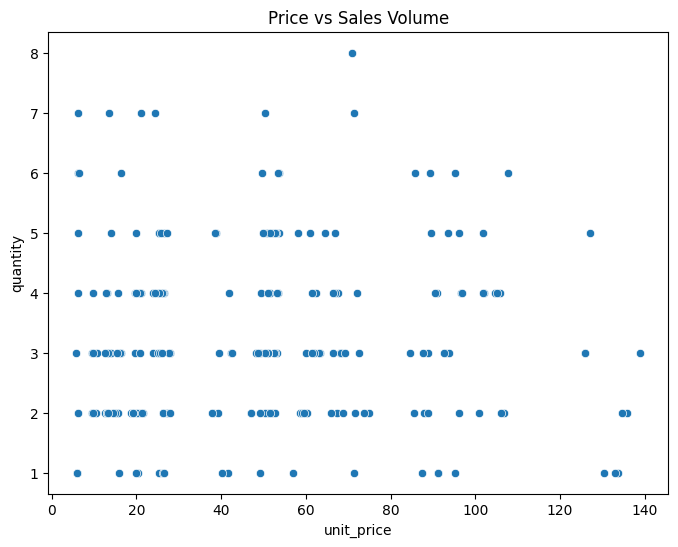

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar chart: Product category distribution
plt.figure(figsize=(8,6))
sns.countplot(x="category", data=df)
plt.title("Product Category Distribution")
plt.xticks(rotation=45)
plt.show()

# Line chart: Sales volume over time
plt.figure(figsize=(10,6))
df.groupby("sale_date")["quantity"].sum().plot(kind="line")
plt.title("Daily Sales Volume Trend")
plt.xlabel("Date")
plt.ylabel("Sales Volume")
plt.show()

# Pie chart: Sales proportion by product
sales_by_product = df.groupby("product_name")["quantity"].sum()
sales_by_product.plot(kind="pie", autopct="%1.1f%%", figsize=(8,8))
plt.title("Sales Proportion by Product")
plt.ylabel("")
plt.show()

# Scatter plot: Price vs Sales volume
plt.figure(figsize=(8,6))
sns.scatterplot(x="unit_price", y="quantity", data=df)
plt.title("Price vs Sales Volume")
plt.show()
